# PCA SUI BENZADATI

## lettura benzadati

---

A quanto pare python può leggere i file `.mat`

In [1]:
from scipy import io as s_io
mat = s_io.loadmat('data/spectra.mat')

In [2]:
import numpy as np

ottani = np.zeros(mat['octane'].shape[0], dtype=np.float64)
spettri = np.zeros((mat['NIR'].shape[0], mat['NIR'].shape[1]), dtype=np.float64)
for i, (o, s) in enumerate(zip(mat['octane'], mat['NIR'])):
    ottani[i] = float(mat['octane'][i][0])
    spettri[i] = s

In [3]:
# indici che ordinerebbero l'array ottano in modo crescente
indici_ordinamento = np.argsort(ottani)

# applico indici a entrambi per riordinarli in sincrono
ottano_ordinato = ottani[indici_ordinamento]
spettri_ordinati = spettri[indici_ordinamento]

N = ottano_ordinato.shape[0]

# vettore delle risposte
labels = np.concatenate((np.zeros(int(N/2)), np.ones(int(N/2))))

In [4]:
import pickle as pkl

with open('data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']

In [5]:
# raccolgo sample di train pos e neg in un unico vettore
train_samples = np.concatenate((train_zeros, train_ones))

---

## SMOOTHING 

In [6]:
"""from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_samples.shape[0]):
    train_samples[i] = savgol_filter(train_samples[i], window_size, poly_order)"""

'from scipy.signal import savgol_filter\n\nwindow_size = 11\npoly_order = 3\n\nfor i in range(train_samples.shape[0]):\n    train_samples[i] = savgol_filter(train_samples[i], window_size, poly_order)'

---

## PCA

### PCA su tutti i benzadati

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tutti_samples_normalizzati = StandardScaler().fit_transform(spettri, labels)
pca = PCA(n_components=None)
tutti_samples_ridotti = pca.fit_transform(tutti_samples_normalizzati)

tutti_samples_autovalori = pca.explained_variance_
tutti_samples_cumsum = np.cumsum(pca.explained_variance_ratio_)
tutti_samples_cumsum

array([0.71724667, 0.88568227, 0.93737926, 0.97510672, 0.98282262,
       0.9867017 , 0.99008753, 0.99203209, 0.99361882, 0.99481229,
       0.99572357, 0.99641397, 0.99698687, 0.99743522, 0.99776074,
       0.99805795, 0.99828512, 0.99847006, 0.99864442, 0.99877727,
       0.99889961, 0.99901177, 0.99910577, 0.99919588, 0.99928013,
       0.99935367, 0.99940756, 0.99945654, 0.9995018 , 0.999543  ,
       0.9995813 , 0.99961823, 0.99964995, 0.99967943, 0.99970791,
       0.99973262, 0.99975637, 0.99977693, 0.9997966 , 0.99981498,
       0.99983159, 0.99984705, 0.99986188, 0.99987551, 0.99988769,
       0.99989915, 0.99991044, 0.99992033, 0.99992978, 0.99993897,
       0.99994748, 0.99995575, 0.99996356, 0.99997101, 0.99997766,
       0.99998398, 0.99998985, 0.99999519, 1.        , 1.        ])

### PCA sui benzadati di train

#### somma comulativa

In [8]:
train_scaler = StandardScaler()

train_normalizzati = train_scaler.fit_transform(train_samples, train_labels)
train_pca = PCA(n_components=None)
train_samples_ridotti = train_pca.fit_transform(train_normalizzati)

train_samples_autovalori = train_pca.explained_variance_
train_samples_cumsum = np.cumsum(train_pca.explained_variance_ratio_)
train_samples_cumsum

array([0.74407258, 0.89563829, 0.94394601, 0.97466577, 0.98253369,
       0.98668918, 0.98996473, 0.99222912, 0.9938885 , 0.99527734,
       0.99620801, 0.99684375, 0.99737378, 0.99782328, 0.99818498,
       0.99843336, 0.99863734, 0.99882755, 0.99896964, 0.99909424,
       0.9992071 , 0.9992919 , 0.99937414, 0.99944882, 0.99951182,
       0.99956905, 0.99961239, 0.99965396, 0.9996905 , 0.99972449,
       0.99975789, 0.99978515, 0.99981194, 0.99983281, 0.99985225,
       0.99987068, 0.99988798, 0.9999044 , 0.99991868, 0.99993251,
       0.99994495, 0.99995596, 0.99996685, 0.99997667, 0.99998495,
       0.99999268, 1.        , 1.        ])

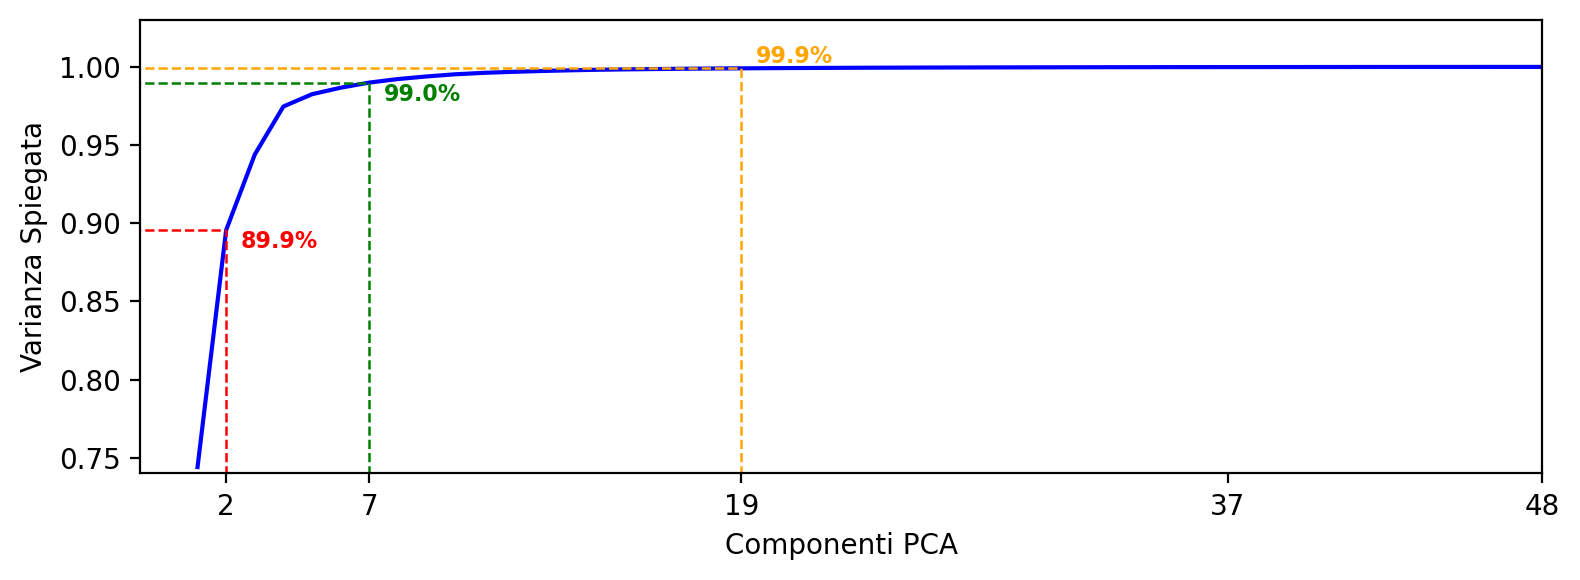

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3), dpi=200)
x_axis=np.arange(1, len(train_samples_cumsum)+1)
y_axis=train_samples_cumsum
plt.plot(x_axis, y_axis, color='blue')

common_options_1 = {'linewidth': 0.9, 'linestyle': '--'}
common_options_2 = {'fontsize': 8, 'fontweight': 'bold'}

# 2 Componenti - 90%
plt.hlines(y=y_axis[1], xmin=-10, xmax=x_axis[1], color='red', **common_options_1)
plt.vlines(x=x_axis[1], ymin=0.5, ymax=y_axis[1], color='red', **common_options_1)
plt.text(x_axis[1] + 0.5, y_axis[1], '89.9%', verticalalignment='top', color='red', **common_options_2)
# 7 Componenti - 99%
plt.hlines(y=y_axis[6], xmin=-10, xmax=x_axis[6], color='green', **common_options_1)
plt.vlines(x=x_axis[6], ymin=0.5, ymax=y_axis[6], color='green', **common_options_1)
plt.text(x_axis[6] + 0.5, y_axis[6], '99.0%', verticalalignment='top', color='green', **common_options_2)
# 20 Componenti - 99.9%
plt.hlines(y=y_axis[19], xmin=-10, xmax=x_axis[19], color='orange', **common_options_1)
plt.vlines(x=x_axis[19], ymin=0.5, ymax=y_axis[19], color='orange', **common_options_1)
plt.text(x_axis[19] + 0.5, y_axis[19], '99.9%', verticalalignment='bottom', color='orange', **common_options_2)

plt.xticks([x_axis[1], x_axis[6], x_axis[19], x_axis[36], x_axis[47]],['2', '7', '19', '37', '48'])

plt.xlim(-1, 48)
plt.ylim(0.74, 1.03)

plt.xlabel('Componenti PCA')
plt.ylabel('Varianza Spiegata')
plt.tight_layout()

---

I loadings mostrano «i punti del segnale in cui le componenti prendono l'informazione»

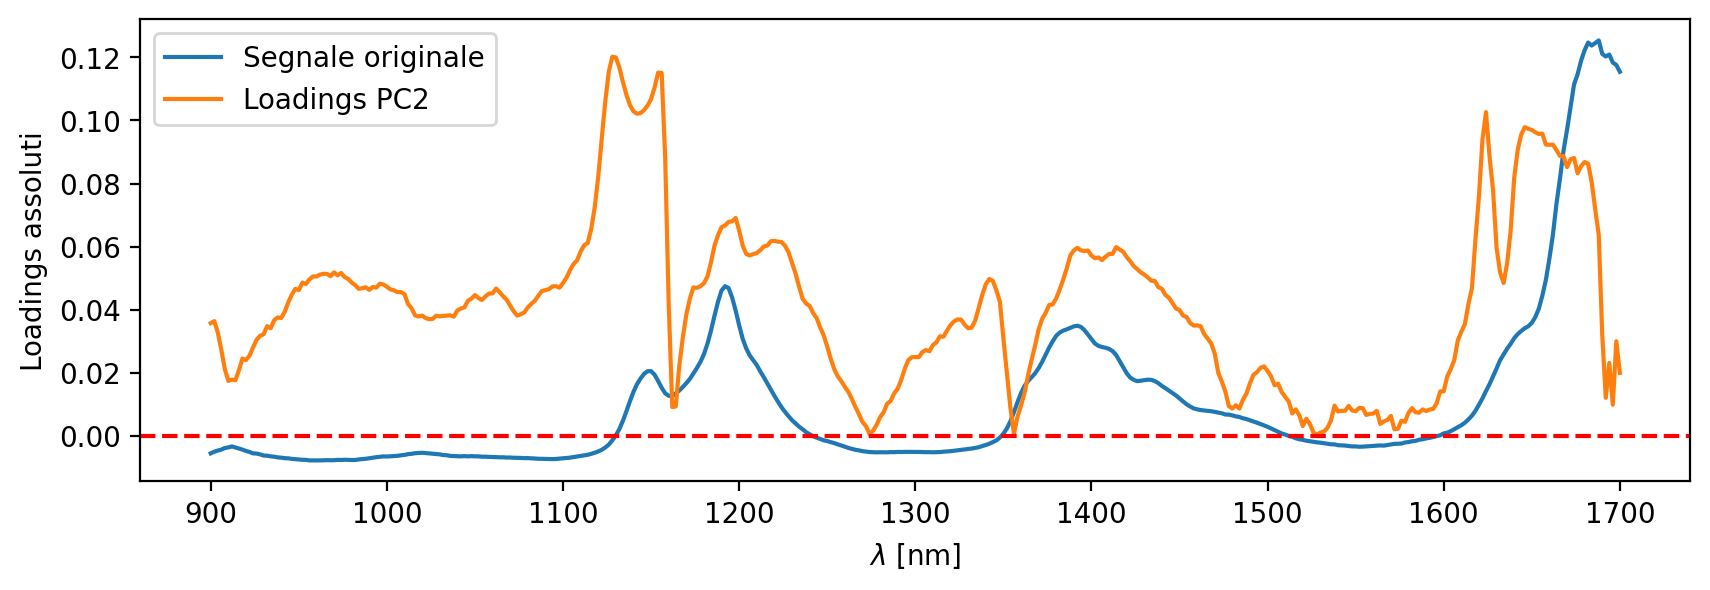

In [10]:
x = np.arange(900, 1702, 2)

# pca.components_ ha forma (n_components, n_features)
# Prendiamo la prima componente
plt.figure(figsize=(10,3), dpi=200)
plt.plot(x, train_samples[-1]/10, label="Segnale originale")
#plt.plot(x, abs(pca.components_[0]), label='Loadings PC1')
plt.plot(x, abs(pca.components_[1]), label='Loadings PC2')
#plt.plot(x, abs(pca.components_[5]), label='Loadings PC3')
plt.axhline(0, color='red', linestyle='--') # Linea dello zero
plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel('Loadings assoluti')
plt.legend()
plt.show()

se uso inverse transform?

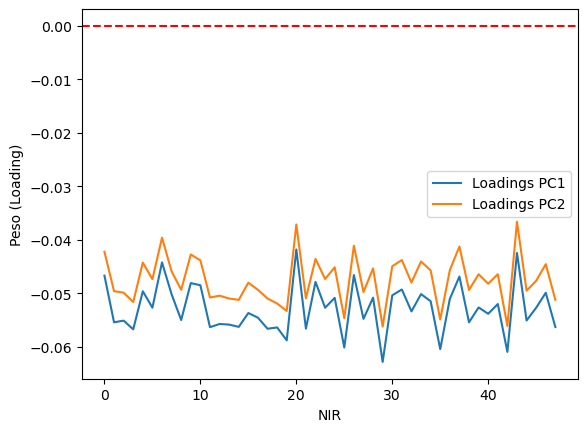

In [11]:
# Reconstruct by projecting the first component back (che fa?)
pca_recovery_1 = train_scaler.inverse_transform(train_pca.inverse_transform(train_samples_ridotti))[:, 0]
# Reconstruct by projecting the second component back
pca_recovery_2 = train_scaler.inverse_transform(train_pca.inverse_transform(train_samples_ridotti))[:, 1]

x_p = range(48)

#plt.plot(x, train_samples[0], label="segnale originale")
plt.plot(x_p, pca_recovery_1, label='Loadings PC1')
plt.plot(x_p, pca_recovery_2, label='Loadings PC2')
plt.axhline(0, color='red', linestyle='--') # Linea dello zero
plt.xlabel('NIR')
plt.ylabel('Peso (Loading)')
plt.legend()
plt.show()

cosa succede se proiettiamo i nostri dati nello spazio delle prime due componenti?

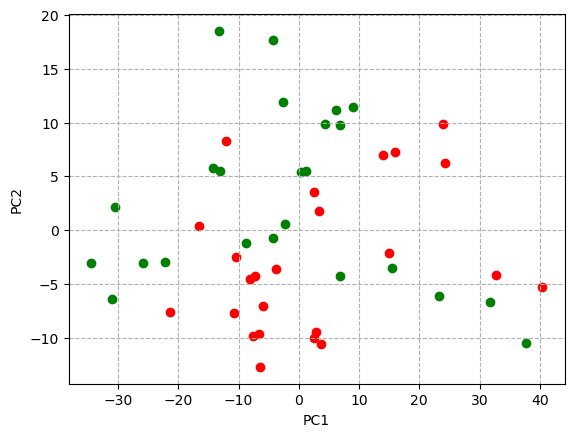

In [12]:
plt.scatter(train_samples_ridotti[:,0][:24], train_samples_ridotti[:,1][:24], color='r')
plt.scatter(train_samples_ridotti[:,0][24:], train_samples_ridotti[:,1][24:], color='g')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(linestyle='--')
plt.show()